In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# -------------------------
# 1) Lire le CSV
# -------------------------
csv_path = "../data/dataset_selection_sans_leger.csv"
df = pd.read_csv(csv_path)

assert "path" in df.columns and "label" in df.columns, "Le CSV doit contenir 'path' et 'label'"
df = df.dropna(subset=["path", "label"]).reset_index(drop=True)

df["exists"] = df["path"].apply(os.path.exists)
missing = (~df["exists"]).sum()
if missing > 0:
    print(f"[WARN] {missing} fichiers manquants dans le CSV. Je les enlève.")
    df = df[df["exists"]].drop(columns=["exists"]).reset_index(drop=True)
else:
    df = df.drop(columns=["exists"])


In [2]:
import numpy as np
from PIL import Image
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    """
    img: PIL RGB
    thr: seuil (0-255). Plus haut => enlève plus (attention à ne pas rogner l'image utile)
    pad: marge ajoutée autour du crop
    """
    arr = np.array(img)  # H,W,3 uint8
    gray = arr.mean(axis=2)  # H,W

    mask = gray > thr  # True = zone utile
    if not mask.any():
        return img  # image totalement sombre -> on ne touche pas

    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()

    # padding + clamp aux bords
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)

    return img.crop((x0, y0, x1 + 1, y1 + 1))

In [3]:

# -------------------------
# Fonctions d'évaluation
# -------------------------

def predict_on_loader(model, loader, device):
    model.eval()
    y_true, y_pred, y_proba = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)

            y_pred.append(probs.argmax(dim=1).cpu().numpy())
            y_true.append(y.cpu().numpy())
            y_proba.append(probs.cpu().numpy())

    return (
        np.concatenate(y_true),
        np.concatenate(y_pred),
        np.concatenate(y_proba),
    )


def plot_confusion_matrix(cm, class_names, title="Confusion Matrix (val)"):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(cm)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


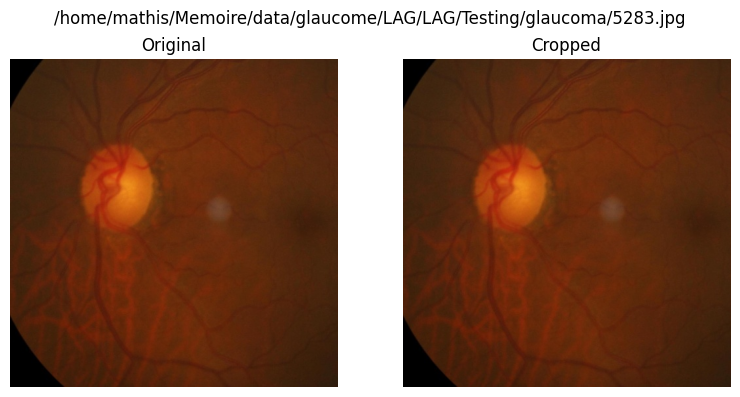

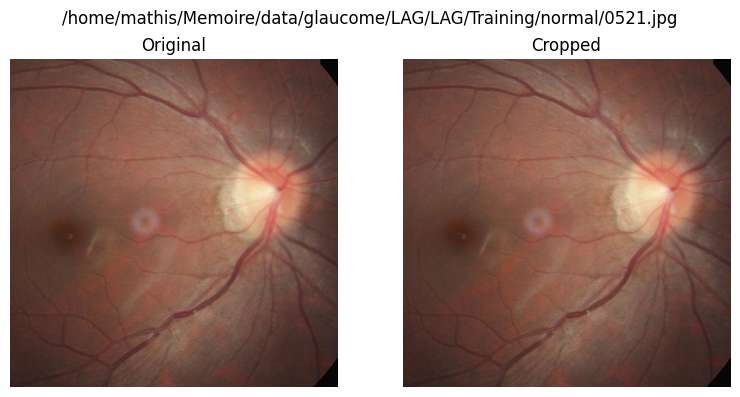

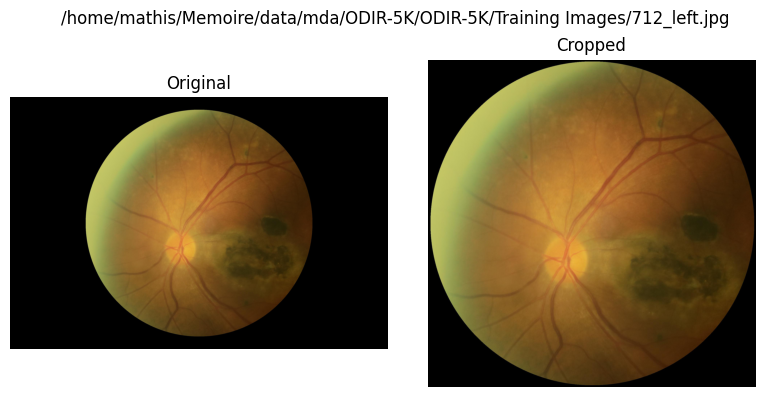

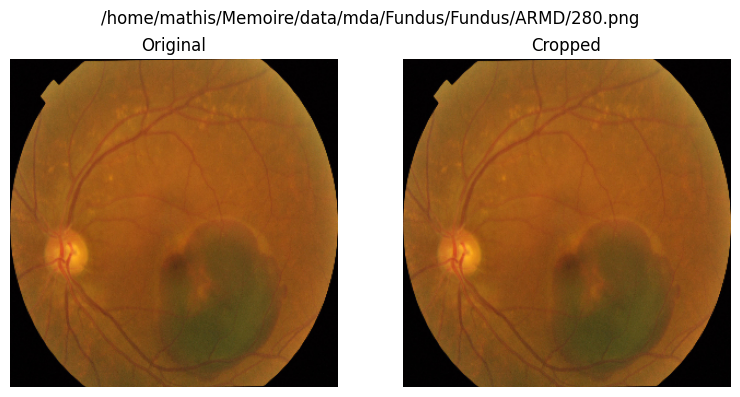

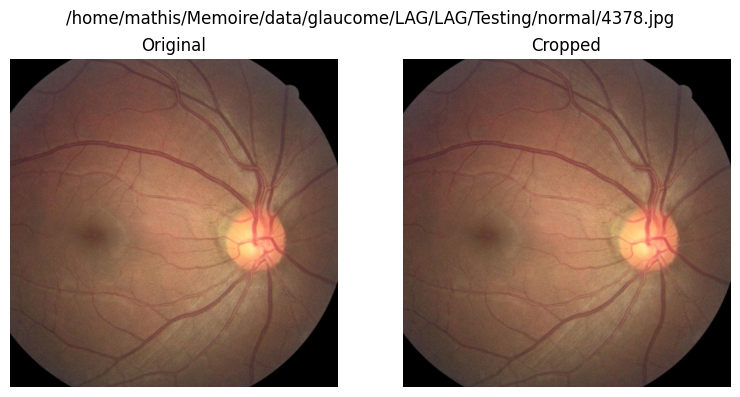

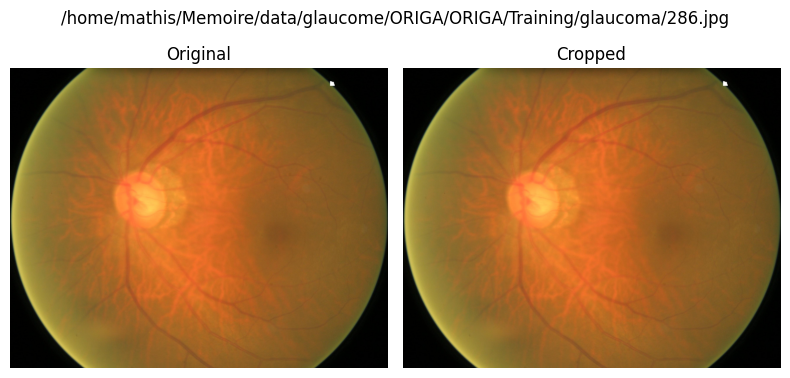

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

sample_paths = df["path"].sample(6, random_state=0).tolist()

for p in sample_paths:
    img = Image.open(p).convert("RGB")
    cropped = crop_black_border_pil(img, thr=10, pad=10)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(cropped)
    axes[1].set_title("Cropped")
    axes[1].axis("off")

    fig.suptitle(p)
    plt.tight_layout()
    plt.show()


In [5]:

# -------------------------
# 2) Encoder les labels
# -------------------------
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

# -------------------------
# 3) Split train/val/test (80/10/10)
# -------------------------
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["y"] if num_classes > 1 else None
)

test_df, val_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["y"] if num_classes > 1 else None
)

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

# -------------------------
# 4) Dataset + Transforms
# Amélioration 2 : augmentation plus forte
# Amélioration 3 : résolution 256→crop 224
# -------------------------
train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2),
])

val_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None, do_crop=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.do_crop = do_crop

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        y = int(row["y"])

        img = Image.open(path).convert("RGB")

        if self.do_crop:
            img = crop_black_border_pil(img, thr=10, pad=10)

        if self.transform:
            img = self.transform(img)

        return img, y


train_ds  = FundusDataset(train_df, transform=train_tfms)
val_ds    = FundusDataset(val_df,   transform=val_tfms)
test_ds   = FundusDataset(test_df,  transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# -------------------------
# 5) Modèle ResNet50 — Amélioration 1
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# Amélioration 1 : fine-tuning progressif
# backbone (layer1-4) : lr faible  |  tête fc : lr plus élevé
optimizer = torch.optim.AdamW([
    {"params": [p for n, p in model.named_parameters() if "fc" not in n], "lr": 1e-5},
    {"params": model.fc.parameters(), "lr": 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

# -------------------------
# 6) Entraînement + Évaluation
# -------------------------
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return running_loss / total, correct / total

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total

best_val_acc = 0.0
epochs = 10

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f}")


Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Train : 4837 | Val : 605 | Test : 605
Epoch 01 | train loss 1.1790 acc 0.5619 | val loss 0.8921 acc 0.7025
Epoch 02 | train loss 0.7506 acc 0.7354 | val loss 0.6256 acc 0.7570
Epoch 03 | train loss 0.5960 acc 0.7734 | val loss 0.5184 acc 0.8000
Epoch 04 | train loss 0.5258 acc 0.8007 | val loss 0.4721 acc 0.8165
Epoch 05 | train loss 0.4816 acc 0.8164 | val loss 0.4356 acc 0.8298
Epoch 06 | train loss 0.4522 acc 0.8276 | val loss 0.4199 acc 0.8380
Epoch 07 | train loss 0.4276 acc 0.8381 | val loss 0.4053 acc 0.8529
Epoch 08 | train loss 0.4000 acc 0.8462 | val loss 0.3864 acc 0.8479
Epoch 09 | train loss 0.3912 acc 0.8495 | val loss 0.3733 acc 0.8562
Epoch 10 | train loss 0.3722 acc 0.8600 | val loss 0.3547 acc 0.8661



=== Confusion Matrix (test) avec labels ===
               Pred_diabete  Pred_glaucome  Pred_mda  Pred_normaux
True_diabete            135              0         5            10
True_glaucome             0            139         0            11
True_mda                  3              0       141            11
True_normaux             13             11        13           113


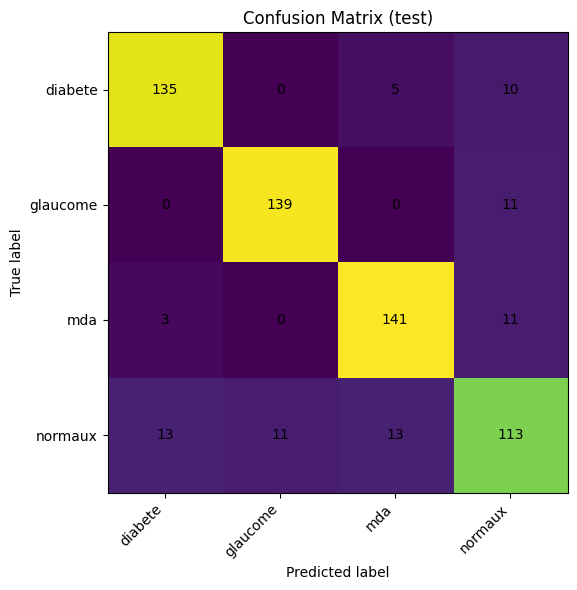


=== Classification report (test) ===
              precision    recall  f1-score   support

     diabete     0.8940    0.9000    0.8970       150
    glaucome     0.9267    0.9267    0.9267       150
         mda     0.8868    0.9097    0.8981       155
     normaux     0.7793    0.7533    0.7661       150

    accuracy                         0.8727       605
   macro avg     0.8717    0.8724    0.8720       605
weighted avg     0.8718    0.8727    0.8722       605



In [6]:
y_true, y_pred, y_proba = predict_on_loader(model, test_loader, device)

# ---- Matrice de confusion + noms (texte)
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in le.classes_],
    columns=[f"Pred_{c}" for c in le.classes_]
)
print("\n=== Confusion Matrix (test) avec labels ===")
print(cm_df)

# ---- Matrice de confusion (figure)
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix (test)")

# ---- Rapport complet
print("\n=== Classification report (test) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))


Nombre d'images mal classées : 77


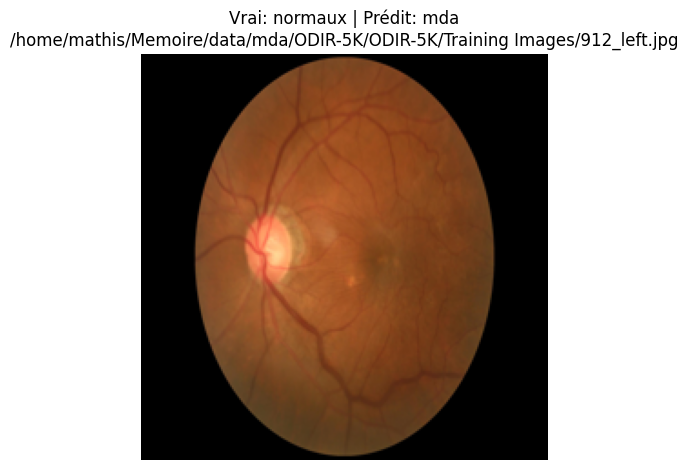

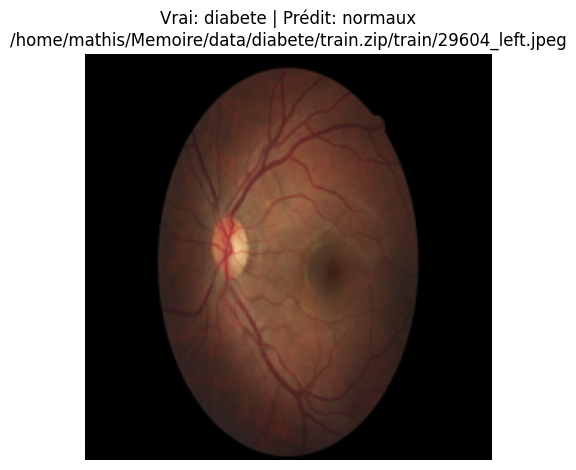

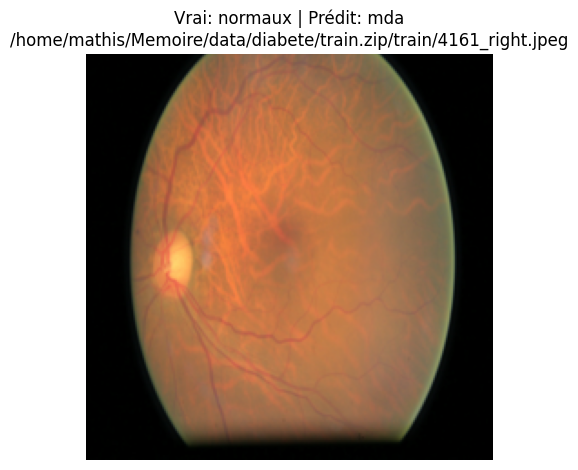

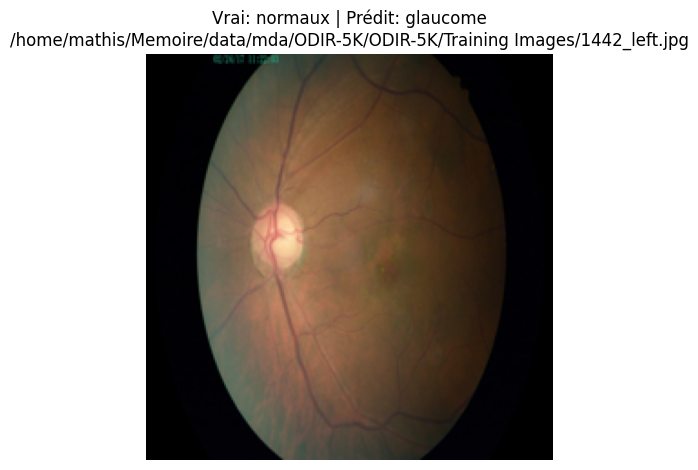

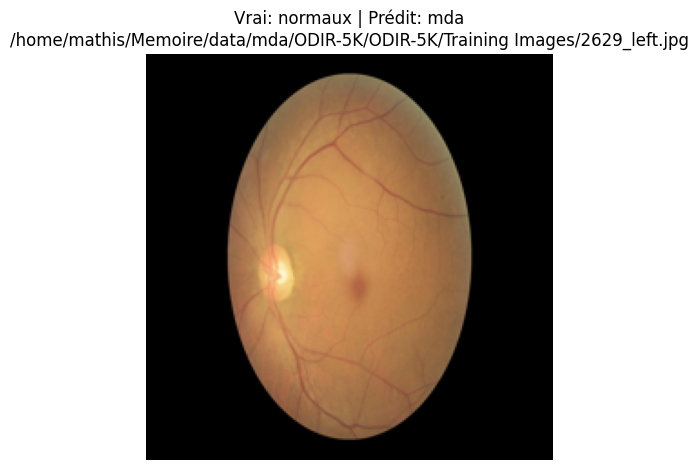

In [7]:

# Exemples d'images mal classées (PyTorch/PIL uniquement)
df_test = test_df.reset_index(drop=True)
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'images mal classées : {len(misclassified_indices)}")

for idx in misclassified_indices[:5]:
    img_path = df_test.iloc[idx]["path"]
    true_label = le.classes_[y_true[idx]]
    pred_label = le.classes_[y_pred[idx]]

    img = Image.open(img_path).convert("RGB").resize((224, 224))

    plt.imshow(img)
    plt.title(f"Vrai: {true_label} | Prédit: {pred_label}\n{img_path}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [8]:

# Amélioration 1 : fine-tuning progressif (cohérent avec cell 7)
optimizer = torch.optim.AdamW([
    {"params": [p for n, p in model.named_parameters() if "fc" not in n], "lr": 1e-5},
    {"params": model.fc.parameters(), "lr": 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=5, factor=0.5)

best_val_acc = 0.0
early_stop_patience = 11
epochs_no_improve = 0
epochs = 200

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        epochs_no_improve = 0

    else:
        epochs_no_improve += 1

    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} train acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} val acc {va_acc:.4f} | "
          f"lr {current_lr:.2e} "
          )

    if epochs_no_improve >= early_stop_patience:
        print(f"Early stopping déclenché à l'epoch {epoch}")
        break


Epoch 01 | train loss 0.3501 train acc 0.8677 | val loss 0.3467 val acc 0.8694 | lr 1.00e-05 
Epoch 02 | train loss 0.3547 train acc 0.8629 | val loss 0.3543 val acc 0.8678 | lr 1.00e-05 
Epoch 03 | train loss 0.3138 train acc 0.8795 | val loss 0.3379 val acc 0.8727 | lr 1.00e-05 
Epoch 04 | train loss 0.3175 train acc 0.8766 | val loss 0.3387 val acc 0.8777 | lr 1.00e-05 
Epoch 05 | train loss 0.3019 train acc 0.8824 | val loss 0.3166 val acc 0.8826 | lr 1.00e-05 
Epoch 06 | train loss 0.2955 train acc 0.8826 | val loss 0.3238 val acc 0.8810 | lr 1.00e-05 
Epoch 07 | train loss 0.2909 train acc 0.8863 | val loss 0.3170 val acc 0.8909 | lr 1.00e-05 
Epoch 08 | train loss 0.2646 train acc 0.9010 | val loss 0.3123 val acc 0.8893 | lr 1.00e-05 
Epoch 09 | train loss 0.2751 train acc 0.8937 | val loss 0.3182 val acc 0.8760 | lr 1.00e-05 
Epoch 10 | train loss 0.2636 train acc 0.8966 | val loss 0.3161 val acc 0.8926 | lr 1.00e-05 
Epoch 11 | train loss 0.2531 train acc 0.8993 | val loss 0.2


=== Confusion Matrix (test) avec labels ===
               Pred_diabete  Pred_glaucome  Pred_mda  Pred_normaux
True_diabete            135              0         2            13
True_glaucome             0            143         0             7
True_mda                  1              0       144            10
True_normaux             13             12         8           117


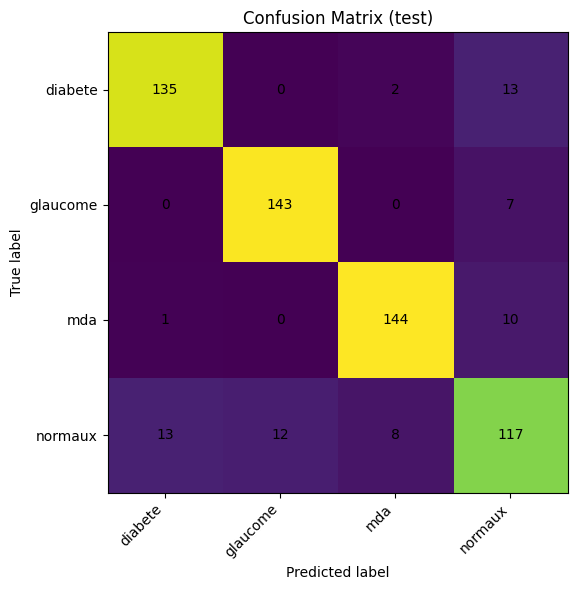


=== Classification report (test) ===
              precision    recall  f1-score   support

     diabete     0.9060    0.9000    0.9030       150
    glaucome     0.9226    0.9533    0.9377       150
         mda     0.9351    0.9290    0.9320       155
     normaux     0.7959    0.7800    0.7879       150

    accuracy                         0.8909       605
   macro avg     0.8899    0.8906    0.8902       605
weighted avg     0.8903    0.8909    0.8905       605



In [9]:
y_true, y_pred, y_proba = predict_on_loader(model, test_loader, device)

# ---- Matrice de confusion + noms (texte)
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in le.classes_],
    columns=[f"Pred_{c}" for c in le.classes_]
)
print("\n=== Confusion Matrix (test) avec labels ===")
print(cm_df)

# ---- Matrice de confusion (figure)
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix (test)")

# ---- Rapport complet
print("\n=== Classification report (test) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))


Nombre d'images mal classées : 66


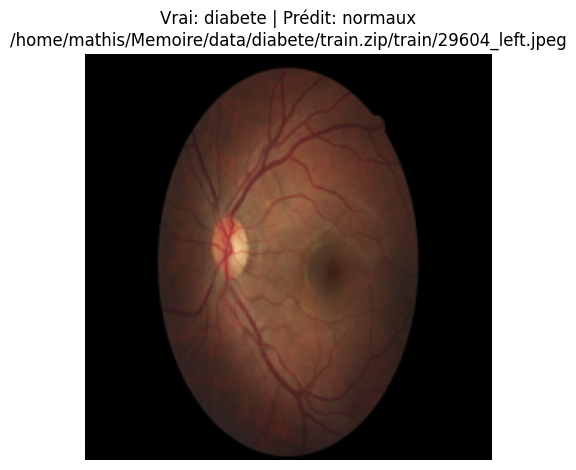

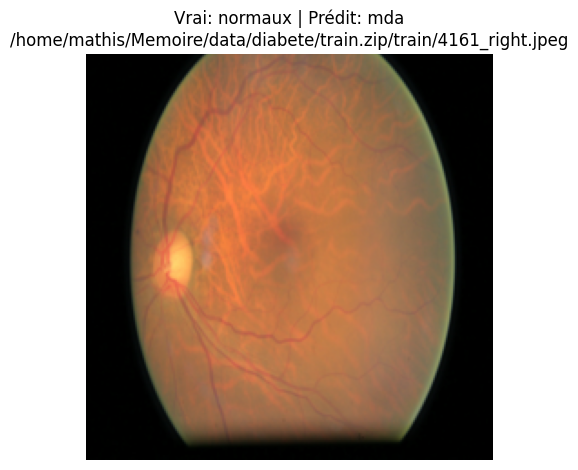

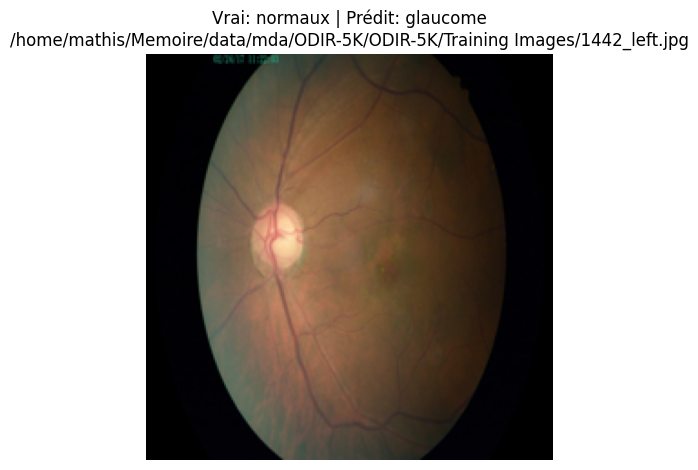

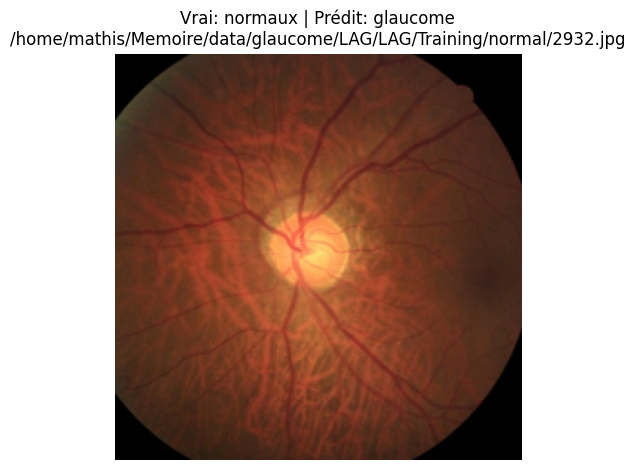

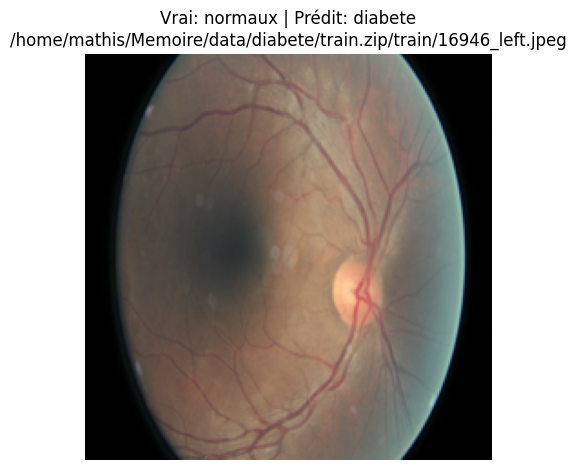

In [10]:

# Exemples d'images mal classées (PyTorch/PIL uniquement)
df_test = test_df.reset_index(drop=True)
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'images mal classées : {len(misclassified_indices)}")

for idx in misclassified_indices[:5]:
    img_path = df_test.iloc[idx]["path"]
    true_label = le.classes_[y_true[idx]]
    pred_label = le.classes_[y_pred[idx]]

    img = Image.open(img_path).convert("RGB").resize((224, 224))

    plt.imshow(img)
    plt.title(f"Vrai: {true_label} | Prédit: {pred_label}\n{img_path}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
